<a href="https://colab.research.google.com/github/ShinCheolHwan-daou/DAOU-FITs-3-ShinCheolHwan/blob/%EC%8B%A4%EC%8A%B5/%5BCS%5D250109_%EC%8B%A4%EC%8A%B524_25%EB%B2%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실습과제 23
고객이탈 예측 모델 구축 실습
1. 고객의 특성을 기반으로 고객이 서비스를 탈퇴할지 여부를 예측

In [48]:
import pandas as pd

# 데이터 로드
data = pd.read_csv('customer_churn.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1000 non-null   int64  
 1   age               1000 non-null   int64  
 2   tenure            1000 non-null   int64  
 3   balance           1000 non-null   float64
 4   num_products      1000 non-null   int64  
 5   has_credit_card   1000 non-null   int64  
 6   is_active_member  1000 non-null   int64  
 7   estimated_salary  1000 non-null   float64
 8   churn             1000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 70.4 KB


# 실습과제 24
샘플 파일 생성

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 랜덤 데이터 생성
np.random.seed(42)

# 고객 수
n = 1000

# 고객 특성 생성
data = {
    'customer_id': np.arange(1, n + 1),
    'age': np.random.randint(18, 70, size=n),
    'tenure': np.random.randint(1, 10, size=n),
    'balance': np.random.uniform(0, 25000, size=n),
    'num_products': np.random.randint(1, 4, size = n),
    'has_credit_card': np.random.choice([0, 1], size=n),
    'is_active_member': np.random.choice([0, 1], size=n),
    'estimated_salary': np.random.uniform(30000, 150000, size=n),
    'churn': np.random.choice([0, 1], size=n, p=[0.8, 0.2])
}

df = pd.DataFrame(data)
df.to_csv('customer_churn.csv', index=False)

df.head()

,customer_id,age,tenure,balance,num_products,has_credit_card,is_active_member,estimated_salary,churn
0,1,56,3,6151.741470,1,1,0,51227.634099,0
1,2,69,3,11917.386876,1,0,1,148480.339030,0
2,3,46,9,9859.133095,1,0,0,83292.426829,0
3,4,32,7,13735.355961,1,1,1,93824.611981,0
4,5,60,5,18671.892903,1,1,0,134834.223448,0


# 실습과제 25
데이터 로딩 및 전처리

In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 로드
data = pd.read_csv('customer_churn.csv')

# 결측값 확인
data.isnull().sum()

,0
customer_id,0
age,0
tenure,0
balance,0
num_products,0
has_credit_card,0
is_active_member,0
estimated_salary,0
churn,0


{'whiskers': [<matplotlib.lines.Line2D at 0x7803e0e19690>,
 'caps': [<matplotlib.lines.Line2D at 0x7803e0e19c90>,
 'boxes': [<matplotlib.lines.Line2D at 0x7803e0e19390>,
 'medians': [<matplotlib.lines.Line2D at 0x7803e0e1a290>,
 'fliers': [<matplotlib.lines.Line2D at 0x7803e0e1a590>,
 'means': []}

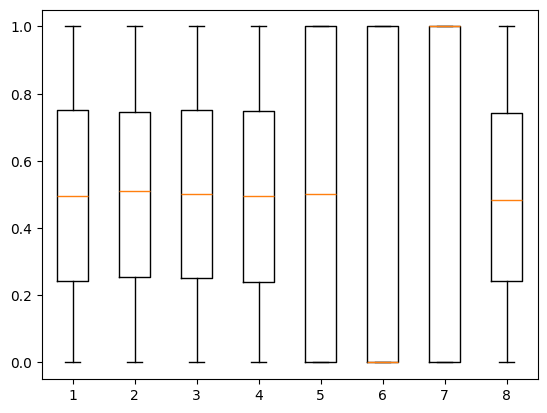

In [51]:
# 특징 및 라벨 분리
X = data.drop('churn', axis=1)
y = data['churn']

# 범주형 변수 처리 (필요한 경우)
X = pd.get_dummies(X, drop_first=True)

# 데이터 분할 (훈련용, 테스트용)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 스케일링
scaler = MinMaxScaler() # 분류에서 최적화를 위해 standard보다 minmax 사용
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

plt.boxplot(X_train)